This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

!pip install keras-nightly keras-hub-nightly --upgrade -q

In [154]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

### Generalization: the goal of machine learning

In the three examples presented in Chapter 4 – predicting movie reviews, topic
classification, and house-price regression – we split the data into a training set, a validation
set, and a test set. The reason not to evaluate the models on the same data they were
trained on quickly became evident: after just a few epochs, performance on never-beforeseen
data started diverging from performance on the training data – which always improves
as training progresses. The models started to overfit. Overfitting happens in every
machine-learning problem.

The fundamental issue in machine learning is the tension between optimization and
generalization. Optimization refers to the process of adjusting a model to get the best
performance possible on the training data (the learning in machine learning), whereas
generalization refers to how well the trained model performs on data it has never seen
before. The goal of the game is to get good generalization, of course, but you don’t control
generalization; you can only fit the model to its training data. If you do that too well,
overfitting kicks in and generalization suffers.

But what causes overfitting? How to achieve good generalization?

#### Underfitting and overfitting

For all models you’ve seen in the previous chapter, performance on the held-out validation
data initially improved as training went on, then inevitably peaked after a while. This
pattern (illustrated in Figure 5.1) is universal. You’ll see it with any model type and any
dataset.

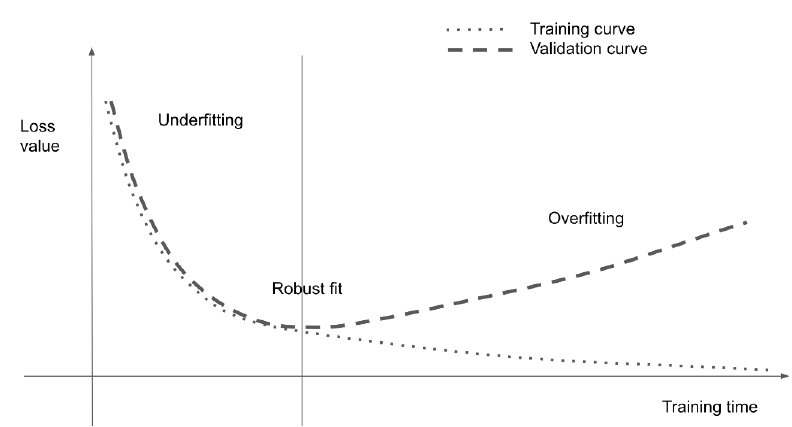

At the beginning of training, optimization and generalization are correlated: the lower the
loss on training data, the lower the loss on test data. While this is happening, your model is
said to be underfit: there is still progress to be made; the network hasn’t yet modeled all
relevant patterns in the training data. But after a certain number of iterations on the
training data, generalization stops improving, validation metrics stall and then begin to
degrade: the model is starting to overfit. That is, it’s beginning to learn patterns that are
specific to the training data but that are misleading or irrelevant when it comes to new
data.

Overfitting is particularly likely to occur when your data is noisy, if it involves
uncertainty, or if it includes rare features. Let’s look at concrete examples.

##### Noisy training data

In real-world datasets, it’s fairly common for some inputs to be invalid. Perhaps a MNIST
digit could be an all-black image, for instance. Or something like this:

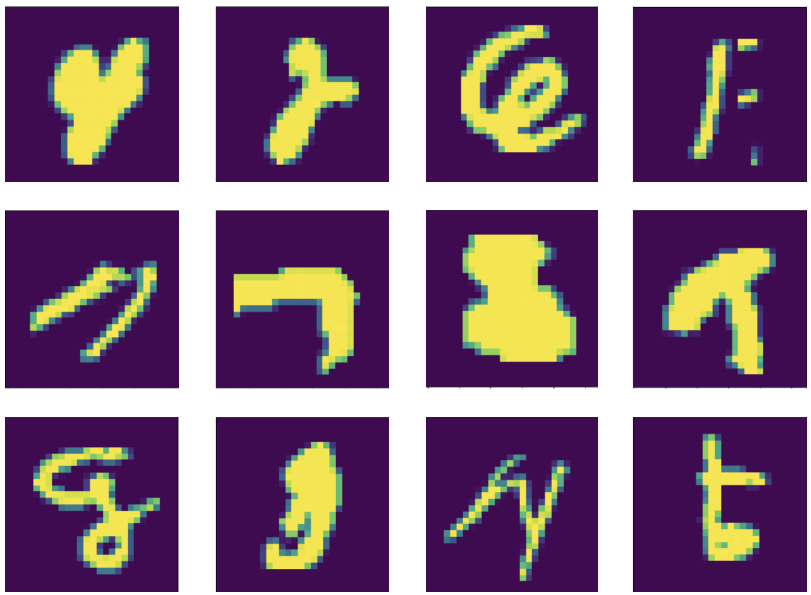

What are these? I don’t know either. But they’re all part of the MNIST training set. What’s
even worse, however, is having perfectly valid inputs that end up mislabeled. Like these:

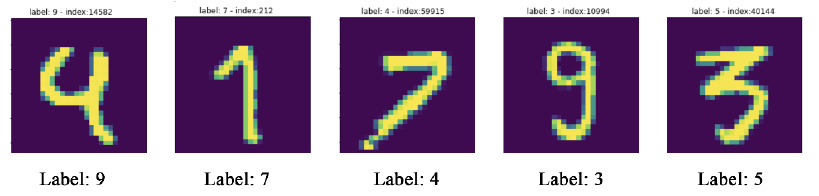

If a model goes out of its way to incorporate such outliers, its generalization performance
will degrade, as shown in Figure 5.4. For instance, a 4 that looks very close to the
mislabeled 4 above may end up getting classified as a 9.

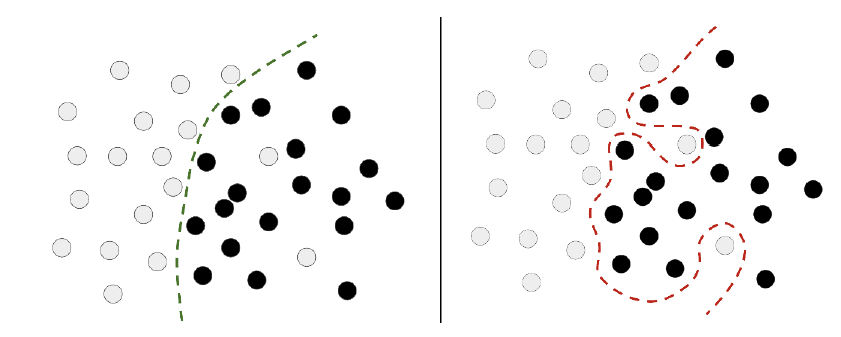

##### Ambiguous features

Not all data noise comes from inaccuracies – even perfectly clean and neatly labeled data
can be noisy, when the problem involves uncertainty and ambiguity. In classification tasks,
it is often the case that some regions of the input feature space are associated with
multiple classes at the same time. Let’s say you’re developing a model that takes an image
of a banana and predicts whether the banana is unripened, ripe, or rotten. These categories
have no objective boundaries, so the same picture might be classified as either unripened
or ripe by different human labelers. Similarly, many problems involve randomness. You
could use atmospheric pressure data to predict whether it will rain tomorrow, but the exact
same measurements may be followed sometimes by rain, sometimes by a clear sky – with
some probability.

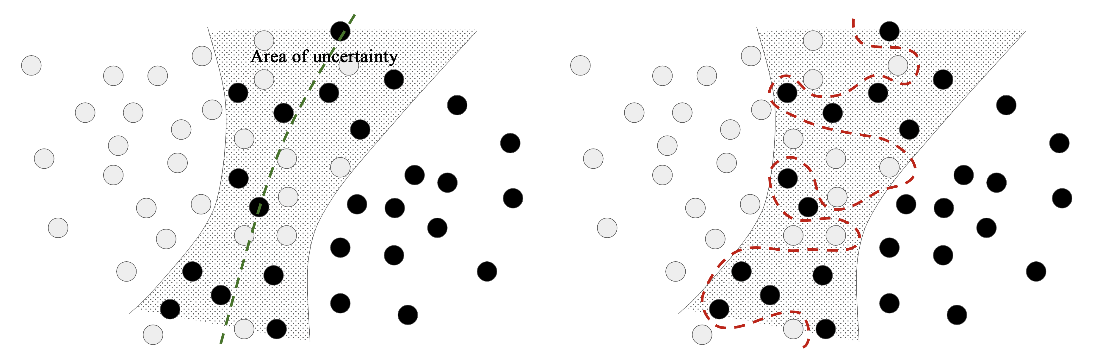

A model could overfit to such probabilistic data by being too confident about ambiguous
regions of the feature space, like in Figure 5.5. A more robust fit would ignore individual
data points and look at the bigger picture.

##### Rare features and spurious correlations

If you’ve only ever seen two orange tabby cats in your life, and they both happened to be
terribly antisocial, you might infer that orange tabby cats are generally likely to be
antisocial. That’s overfitting: if you had been exposed to a wider variety of cats, including
more orange ones, you’d have learned that cat color is not well correlated with character.

Likewise, machine learning models trained on datasets that include rare feature values
are highly susceptible to overfitting. In a sentiment classification task, if the word
“cherimoya” (a fruit native to the Andes) only appears in one text in the training data, and
this text happens to be negative in sentiment, a poorly-regularized model might put a very
high weight on this word and always classify new texts that mention cherimoyas as
negative. Whereas, objectively, there’s nothing negative about the cherimoya. [1]

Importantly, a feature value doesn’t need to occur only a couple of times to lead to
spurious correlations. Consider a word that occurs in 100 samples in your training data, and
that’s associated with a positive sentiment 54% of the time and with a negative sentiment
46% of the time. That difference may well be a complete statistical fluke, yet, your model is
likely to learn to leverage that feature for its classification task. This is one of the most
common sources of overfitting.

Here’s a striking example. Take MNIST. Create a new training set by concatenating 784
white-noise dimensions to the existing 784 dimensions of the data – so half of the data is
now noise. For comparison, also create an equivalent dataset by concatenating 784 allzeros
dimensions. Our concatenation of meaningless features does not at all affect the
information content of the data: we’re only adding irrelevant data points. Human
classification accuracy wouldn’t be affected by these transformations at all.

In [155]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [156]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8636 - loss: 0.4471 - val_accuracy: 0.9287 - val_loss: 0.2558
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9325 - loss: 0.2287 - val_accuracy: 0.9431 - val_loss: 0.1982
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9548 - loss: 0.1541 - val_accuracy: 0.9433 - val_loss: 0.1904
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9679 - loss: 0.1089 - val_accuracy: 0.9607 - val_loss: 0.1374
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0811 - val_accuracy: 0.9561 - val_loss: 0.1458
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9841 - loss: 0.0560 - val_accuracy: 0.9579 - val_loss: 0.1438
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0419 - val_accuracy: 0.9604 - val_loss: 0.1418
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9936 - loss: 0.0272 - val_accuracy: 0.

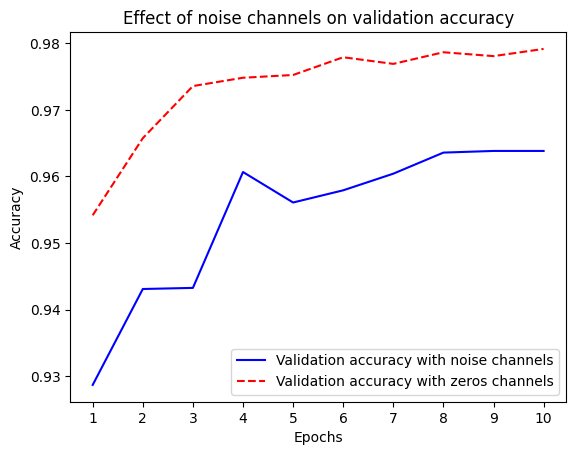

In [157]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("mnist_with_added_noise_channels_or_zeros_channels.png", dpi=300)

Despite the data holding the same information in both cases, the validation accuracy of the
model trained with noise channels ends up about one percentage point lower – purely
through the influence of spurious correlations. The more noise channels you would add, the
further accuracy would degrade.

Noisy features inevitably lead to overfitting. As such, in cases where you aren’t sure
whether the features you have are informative or distracting, it’s common to do feature
selection before training. Restricting the IMDB data to the top 10,000 most common words
was a crude form of feature selection, for instance. The typical way to do feature selection
is to compute some usefulness score for each feature available – a measure of how
informative the feature is with respect to the task, such as the mutual information between
the feature and the labels – and only keep features that are above some threshold. Doing
this would filter out the white-noise channels in the example above.

#### The nature of generalization in deep learning

A remarkable fact about deep learning models is that they can be trained to fit anything, as
long as they have enough representational power.
Don’t believe me? Try shuffling the order of the MNIST labels and train a model on that.
Even though there is no relationship whatsoever between the inputs and the shuffled labels,
the training loss goes down just fine, even with a relatively small model. Naturally, the
validation loss does not improve at all over time, since there is no possibility of
generalization in this setting.

In [158]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1025 - loss: 2.3164 - val_accuracy: 0.1019 - val_loss: 2.3050
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1191 - loss: 2.2993 - val_accuracy: 0.1060 - val_loss: 2.3110
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1289 - loss: 2.2904 - val_accuracy: 0.1024 - val_loss: 2.3181
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1391 - loss: 2.2785 - val_accuracy: 0.1058 - val_loss: 2.3265
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1513 - loss: 2.2632 - val_accuracy: 0.1017 - val_loss: 2.3388
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1669 - loss: 2.2439 - val_accuracy: 0.1014 - val_loss: 2.3538
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1832 - loss: 2.2211 - val_accuracy: 0.1042 - val_loss: 2.3597
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1954 - loss: 2.1946 - val_accu

## Another explanation of manifold hypothesis:
https://colah.github.io/posts/2014-03-NN-Manifolds-Topology/

In fact, you don’t even need to do this with MNIST data – you could just generate whitenoise
inputs and random labels. You could fit a model on that, too, as long as it has enough
parameters. It would just end up memorizing specific inputs, much like a Python dictionary.
If this is the case, then how come deep learning models generalize at all? Shouldn’t they
just learn an ad-hoc mapping between training inputs and targets, like a fancy dict? What
expectation can we have that this mapping will work for new inputs?

As it turns out, the nature of generalization in deep learning has rather little to do with
deep learning models themselves, and much to do with the structure of information in the
real world. Let’s take a look at what’s really going on here.

##### The manifold hypothesis

The input to a MNIST classifier (before preprocessing) is a 28x28 array of integers between
0 and 255. The total number of possible input values is thus 256 to the power of 784 –
much greater than the number of atoms in the universe. However, very few of these inputs
would look like valid MNIST samples: actual handwritten digits only occupy a tiny subspace
of the parent space of all possible 28x28 uint8 arrays. What’s more, this subspace isn’t just
a set of points sprinkled at random in the parent space: it is highly structured.

First, the subspace of valid handwritten digits is continuous: if you take a sample and
modify it a little, it will still be recognizable as the same handwritten digit. Further, all
samples in the valid subspace are connected by smooth paths that run through the
subspace. This means that if you take two random MNIST digits A and B, there exists a
sequence of “intermediate” images that morph A into B, such that two consecutive digits
are very close to each other (see Figure 5.7). Perhaps there will be a few ambiguous
shapes close to the boundary between two classes, but even these shapes would still look
very digit-like.

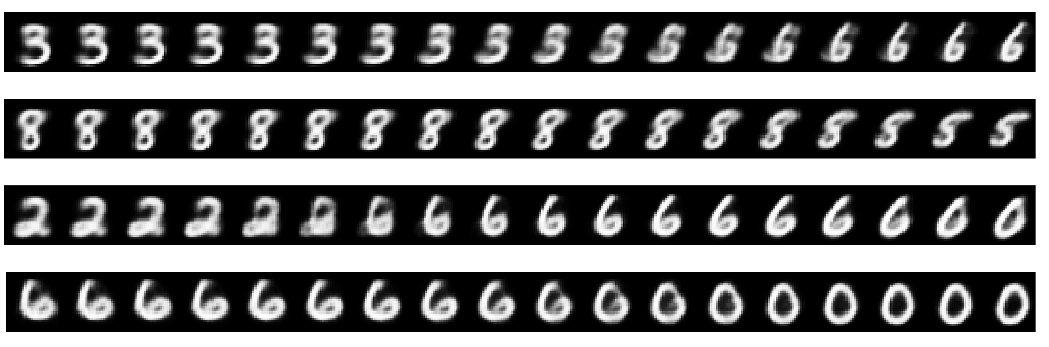

In technical terms, you would say that handwritten digits form a manifold within the space
of possible 28x28 uint8 arrays. That’s a big word, but the concept is pretty intuitive. A
“manifold” is a lower-dimensional subspace of some parent space, that is locally similar to a
linear (Euclidean) space. For instance, a smooth curve in the plane is a 1D manifold within
a 2D space, because for every point of the curve, you can draw a tangent (the curve can be
approximated by a line in every point). A smooth surface within a 3D space is a 2D
manifold. And so on.

More generally, the manifold hypothesis posits that all natural data lies on a lowdimensional
manifold within the high-dimensional space where it is encoded. That’s a pretty
strong statement about the structure of information in the universe. As far as we know, it’s
accurate, and it’s the reason why deep learning works. It’s true for MNIST digits, but also
for human faces, tree morphology, the sounds of the human voice, and even natural
language.

The manifold hypothesis implies that:

Machine learning models only have to fit relatively simple, lowdimensional,
highly-structured subspaces within their potential input
space (latent manifolds).

Within one of these manifolds, it’s always possible to interpolate between
two inputs, that is to say, morph one into another via a continuous path
along which all points fall on the manifold.

The ability to interpolate between samples is the key to understanding generalization in
deep learning.

##### Interpolation as a source of generalization

If you work with data points that can be interpolated, you can start making sense of points
you’ve never seen before, by relating them to other points that lie close on the manifold. In
other words, you can make sense of the totality of the space using only a sample of the
space. You can use interpolation to fill in the blanks.

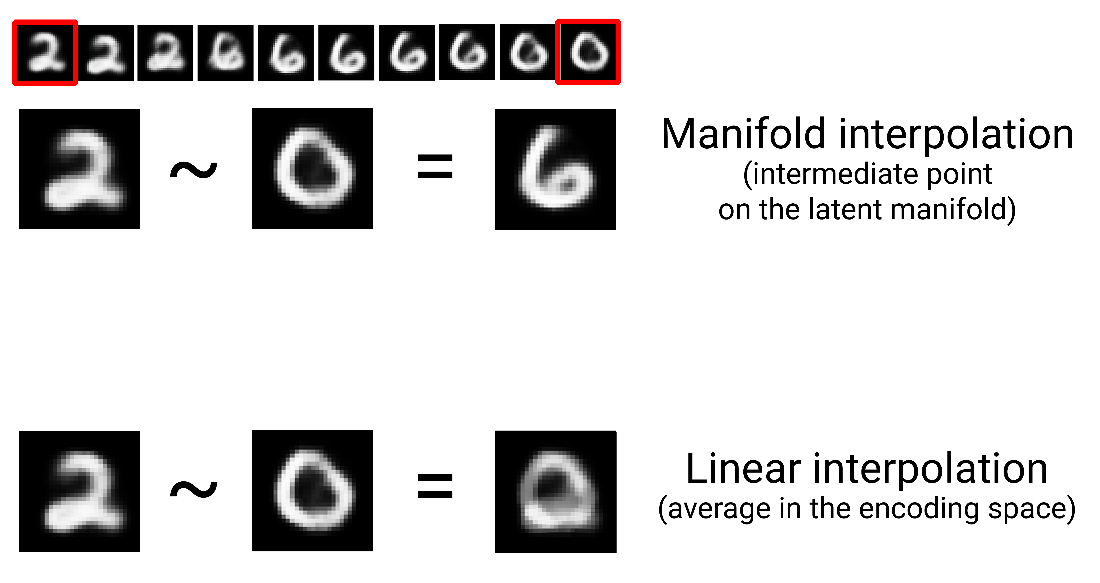

Note that interpolation on the latent manifold is different from linear interpolation in the
parent space, as illustrated in Figure 5.8. For instance, the average of pixels between two
MNIST digits is usually not a valid digit.

Crucially, while deep learning achieves generalization via interpolation on a learned
approximation of the data manifold, it would be a mistake to assume that interpolation is all
there is to generalization. It’s the tip of the iceberg. Interpolation can only help you make
sense of things that are very close to what you’ve seen before: it enables local
generalization. But remarkably, humans deal with extreme novelty all the time, and they do
just fine. You don’t need to be trained in advance on countless examples of every situation
you’ll ever have to encounter. Every single one of your days is different from any day
you’ve experienced before, and different from any day experienced by anyone since the
dawn of humanity. You can switch between spending a week in NYC, a week in Shanghai,
and a week in Bangalore without requiring thousands of lifetimes of learning and rehearsal
for each city.

Humans are capable of extreme generalization, which is enabled by cognitive
mechanisms other than interpolation – abstraction, symbolic models of the world,
reasoning, logic, common sense, innate priors about the world. What we generally call
reason, as opposed to intuition and pattern recognition. The latter are largely interpolative
in nature, but the former isn’t. Both are essential to intelligence. We’ll talk more about this
in Chapter 19.

##### Why deep learning works

Remember the crumpled paper ball metaphor from Chapter 2? A sheet of paper represents
a 2D manifold within 3D space. A deep learning model is a tool for uncrumpling paper balls,
that is, for disentangling latent manifolds.

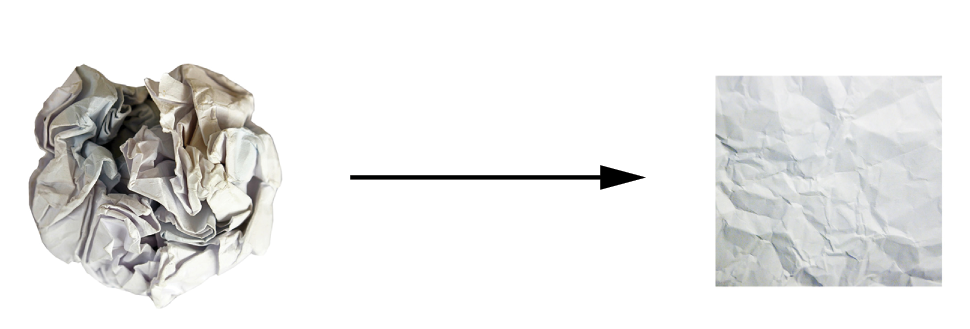

A deep-learning model is basically a very high-dimensional curve. A curve that is smooth
and continuous (with additional constraints on its structure, originating from model
architecture priors), since it needs to be differentiable. And that curve is fitted to data
points via gradient descent – smoothly and incrementally. By construction, deep learning is
about taking a big, complex curve – a manifold – and incrementally adjusting its
parameters until it fits some training data points.

The curve involves enough parameters that it could fit anything – indeed, if you let your
model train for long enough, it will effectively end up purely memorizing its training data
and won’t generalize at all. However, the data you’re fitting to isn’t made of isolated points
sparsely distributed across the underlying space. Your data forms a highly-structured, lowdimensional
manifold within the input space – that’s the manifold hypothesis. And because
fitting your model curve to this data happens gradually and smoothly over time, as gradient
descent progresses, there will be an intermediate point during training at which the model
roughly approximates the natural manifold of the data, as you can see in Figure 5.10.

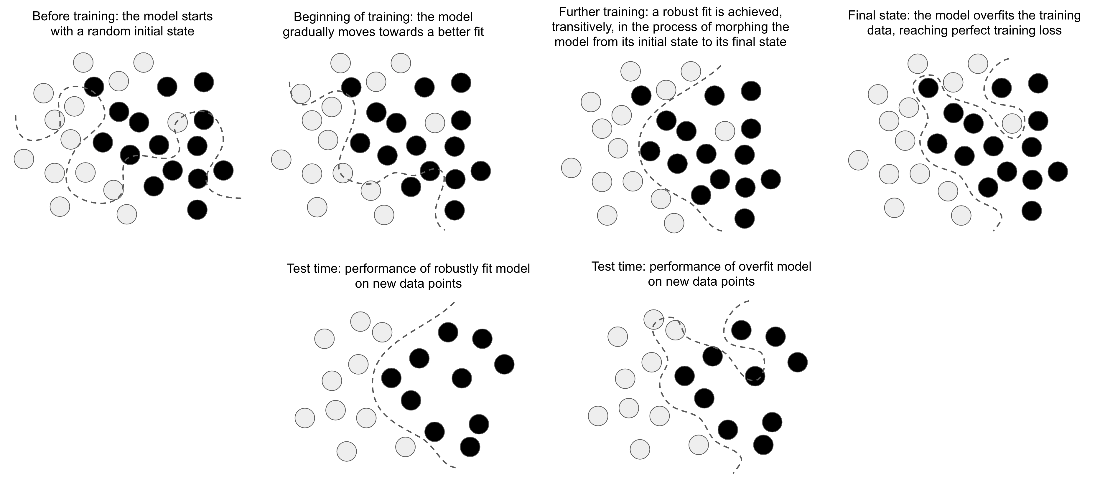

Moving along the curve learned by the model at that point will come close to moving along
the actual latent manifold of the data – as such, the model will be capable of making sense
of never-seen-before inputs via interpolation between training inputs.

Besides the trivial fact that they have sufficient representational power, there are a few
properties of deep learning models that make them particularly well-suited to learning
latent manifolds:

1. Deep learning models implement a smooth, continuous mapping from
their inputs to their outputs. It has to be smooth and continuous because
it must be differentiable, by necessity (you couldn’t do gradient descent
otherwise). This smoothness helps approximate latent manifolds, which
follow the same properties.
2. Deep learning models tend to be structured in a way that mirrors the
“shape” of the information in their training data (via architecture priors).
This is the case in particular for image-processing models (see Chapters 8
through Chapter 12) and sequence-processing models (see Chapter 13).
More generally, deep neural networks structure their learned
representations in a hierarchical and modular way, which echoes the way
natural data is organized.

##### Training data is paramount

While deep learning is indeed well-suited to manifold learning, the power to generalize is
more a consequence of the natural structure of your data than a consequence of any
property of your model. You’ll only be able to generalize if your data forms a manifold
where points can be interpolated. The more informative and the less noisy your features
are, the better you will be able to generalize, since your input space will be simpler and
better-structured. Data curation and feature engineering are essential to generalization.
Further, because deep learning is curve-fitting, for a model to perform well, it needs to
be trained on a dense sampling of its input space. A “dense sampling” in this context
means that the training data should densely cover the entirety of the input data manifold
(see Figure 5.11). This is especially true near decision boundaries. With a sufficiently dense
sampling, it becomes possible to make sense of new inputs by interpolating between past
training inputs, without having to use common-sense, abstract reasoning, or external
knowledge about the world – all things that machine learning models have no access to.

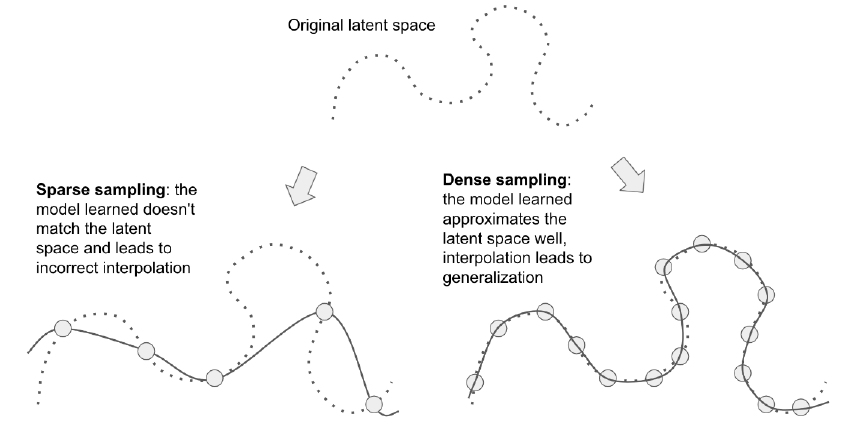

As such, you should always keep in mind that the best way to improve a deep learning
model is to train it on more data or better data (of course, adding overly noisy or
inaccurate data will harm generalization). A denser coverage of the input data manifold will
yield a model that generalizes better. You should never expect a deep learning model to
perform anything more than crude interpolation between its training samples, and thus,
you should do everything you can to make interpolation as easy as possible. The only thing
you will find in a deep learning model is what you put into it: the priors encoded in its
architecture, and the data it was trained on.

When getting more data isn’t possible, the next-best solution is to modulate the quantity
of information that your model is allowed to store, or to add constraints on the smoothness
of the model curve. If a network can only afford to memorize a small number of patterns,
or very regular patterns, the optimization process will force it to focus on the most
prominent patterns, which have a better chance of generalizing well. The process of fighting
overfitting this way is called regularization. We’ll review regularization techniques in-depth
in section 5.4.4.

Before you can start tweaking your model to help it generalize better, you need a way to
assess how your model is currently doing. In the following section, you’ll learn about how
you can monitor generalization during model development: model evaluation.

### Evaluating machine-learning models

You can only control what you can observe. Since your goal is to develop models that can
successfully generalize to new data, it’s essential to be able to reliably measure the
generalization power of your model. In this section, we’ll formally introduce the different
ways you can evaluate machine-learning models. You’ve already seen most of them in
action in the previous chapter.

#### Training, validation, and test sets

Evaluating a model always boils down to splitting the available data into three sets:
training, validation, and test. You train on the training data and evaluate your model on the
validation data. Once your model is ready for prime time, you test it one final time on the
test data, which is meant to be as similar as possible to production data. Then you can
deploy the model in production.

You may ask, why not have two sets: a training set and a test set? You’d train on the
training data and evaluate on the test data. Much simpler!

The reason is that developing a model always involves tuning its configuration: for
example, choosing the number of layers or the size of the layers (called the
hyperparameters of the model, to distinguish them from the parameters, which are the
network’s weights). You do this tuning by using as a feedback signal the performance of the
model on the validation data. In essence, this tuning is a form of learning: a search for a
good configuration in some parameter space. As a result, tuning the configuration of the
model based on its performance on the validation set can quickly result in overfitting to the
validation set, even though your model is never directly trained on it.

Central to this phenomenon is the notion of information leaks. Every time you tune a
hyperparameter of your model based on the model’s performance on the validation set,
some information about the validation data leaks into the model. If you do this only once,
for one parameter, then very few bits of information will leak, and your validation set will
remain reliable to evaluate the model. But if you repeat this many times – running one
experiment, evaluating on the validation set, and modifying your model as a result – then
you’ll leak an increasingly significant amount of information about the validation set into the
model.

At the end of the day, you’ll end up with a model that performs artificially well on the
validation data, because that’s what you optimized it for. You care about performance on
completely new data, not the validation data, so you need to use a completely different,
never-before-seen dataset to evaluate the model: the test dataset. Your model shouldn’t
have had access to any information about the test set, even indirectly. If anything about
the model has been tuned based on test set performance, then your measure of
generalization will be flawed.

Splitting your data into training, validation, and test sets may seem straightforward, but
there are a few advanced ways to do it that can come in handy when little data is available.
Let’s review three classic evaluation recipes: simple hold-out validation, K-fold validation,
and iterated K-fold validation with shuffling. We’ll also talk about the use of common-sense
baselines to check that your training is going somewhere.

##### Simple hold-out validation

Set apart some fraction of your data as your test set. Train on the remaining data, and
evaluate on the test set. As you saw in the previous sections, in order to prevent
information leaks, you shouldn’t tune your model based on the test set, and therefore you
should also reserve a validation set.
Schematically, hold-out validation looks like Figure 5.12. The following listing shows a
simple implementation.

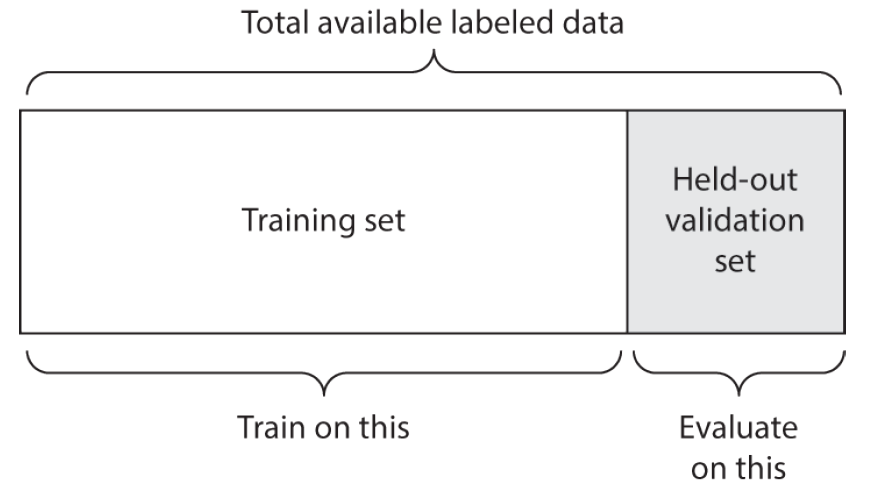

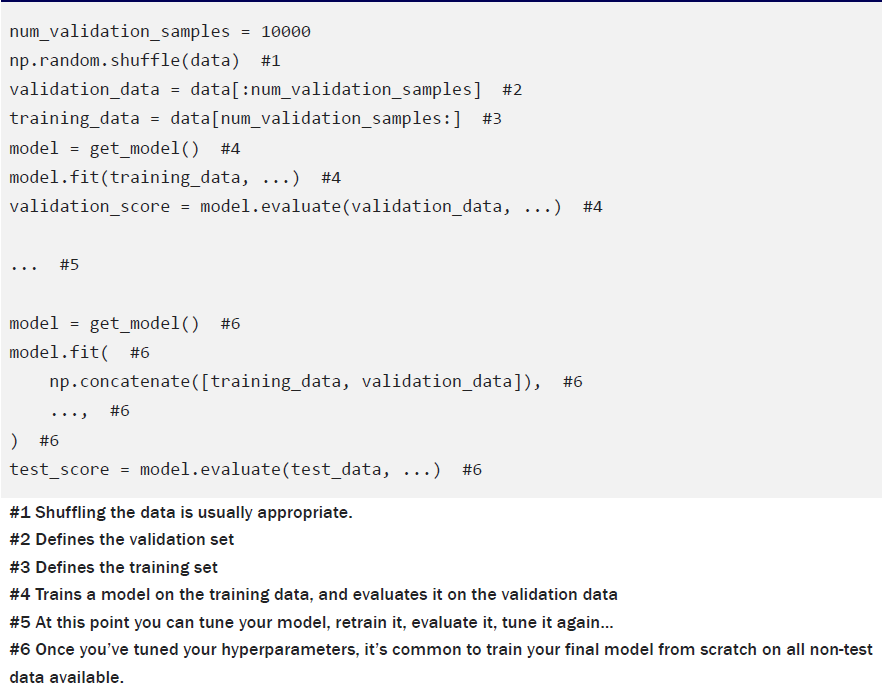

This is the simplest evaluation protocol, and it suffers from one flaw: if little data is
available, then your validation and test sets may contain too few samples to be statistically
representative of the data at hand. This is easy to recognize: if different random shuffling
rounds of the data before splitting end up yielding very different measures of model
performance, then you’re having this issue. K-fold validation and iterated K‑fold validation
are two ways to address this, as discussed next.

##### K-fold validation

With this approach, you split your data into K partitions of equal size. For each partition i,
train a model on the remaining K - 1 partitions, and evaluate it on partition i. Your final
score is then the averages of the K scores obtained. This method is helpful when the
performance of your model shows significant variance based on your train-test split. Like
hold-out validation, this method doesn’t exempt you from using a distinct validation set for
model calibration.

Schematically, K-fold cross-validation looks like Figure 5.13. Listing 5.6 shows a simple
implementation.

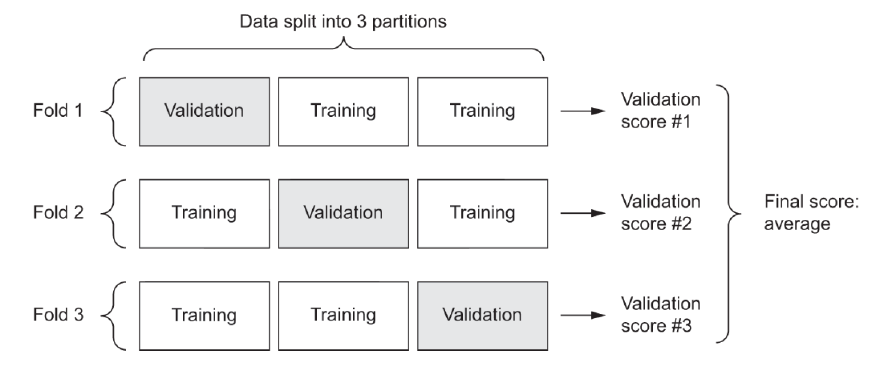

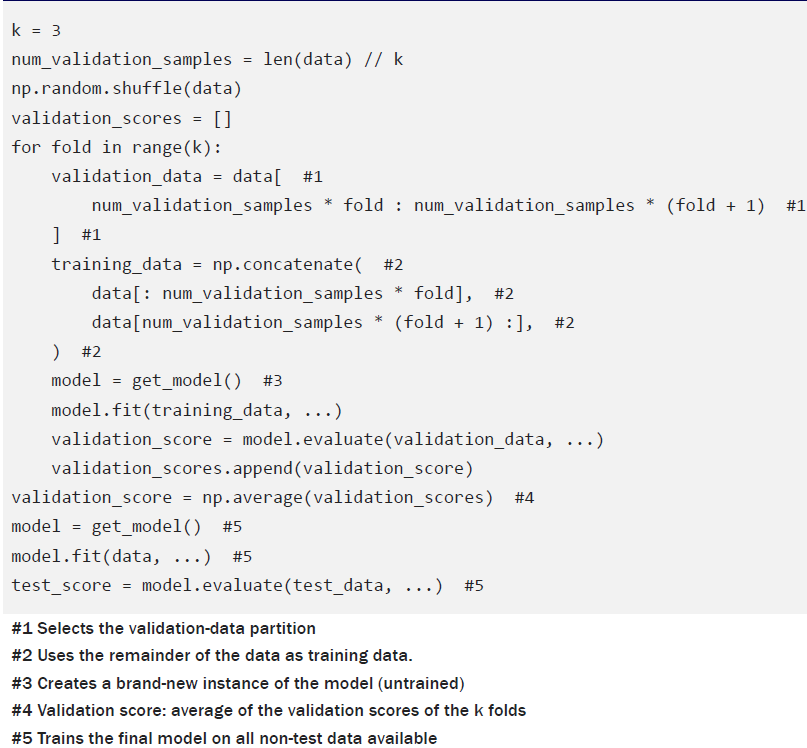

##### Iterated K-fold validation with shuffling

This one is for situations in which you have relatively little data available and you need to
evaluate your model as precisely as possible. I’ve found it to be extremely helpful in Kaggle
competitions. It consists of applying K-fold validation multiple times, shuffling the data
every time before splitting it K ways. The final score is the average of the scores obtained
at each run of K-fold validation. Note that you end up training and evaluating P * K models
(where P is the number of iterations you use), which can be very expensive.

#### Beating a common-sense baseline

Besides the different evaluation protocols you have available, one last thing you should
know about is the use of common-sense baselines.

Training a deep learning model is a bit like pressing a button that launches a rocket in a
parallel world. You can’t hear it or see it. You can’t observe the manifold learning process –
it’s happening in a space with thousands of dimensions, and even if you projected it to 3D,
you couldn’t interpret it. The only feedback you have is your validation metrics – like an
altitude meter on your invisible rocket.

A particularly important point is to be able to tell whether you’re getting off the ground
at all. What was the altitude you started at? Your model seems to have an accuracy of
15%, is that any good? Before you start working with a dataset, you should always pick a
trivial baseline that you’ll try to beat. If you cross that threshold, you’ll know you’re doing
something right: your model is actually using the information in the input data to make
predictions that generalize – you can keep going. This baseline could be performance of a
random classifier, or the performance of the simplest non-machine learning technique you
can imagine.

For instance, in the MNIST digit-classification example, a simple baseline would be a
validation accuracy greater than 0.1 (random classifier); in the IMDB example, it would be
a validation accuracy greater than 0.5. In the Reuters example, it would be around 0.18-
0.19, due to class imbalance. If you have a binary classification problem where 90% of
samples belong to class A and 10% belong to class B, then a classifier that always predicts
A already achieves 0.9 in validation accuracy, and you’ll need to do better than that.

Having a common sense baseline you can refer to is essential when you’re getting
started on a problem no one has solved before. If you can’t beat a trivial solution, your
model is worthless – perhaps you’re using the wrong model, or perhaps the problem you’re
tackling can’t even be approached with machine learning in the first place. Time to go back
to the drawing board.

#### Things to keep in mind about model evaluation

Keep an eye out for the following when you’re choosing an evaluation protocol:

Data representativeness – You want both your training set and test
set to be representative of the data at hand. For instance, if you’re trying
to classify images of digits, and you’re starting from an array of samples
where the samples are ordered by their class, taking the first 80% of the
array as your training set and the remaining 20% as your test set will
result in your training set containing only classes 0–7, whereas your test
set contains only classes 8–9. This seems like a ridiculous mistake, but
it’s surprisingly common. For this reason, you usually should randomly
shuffle your data before splitting it into training and test sets.

The arrow of time – If you’re trying to predict the future given the past
(for example, tomorrow’s weather, stock movements, and so on), you
should not randomly shuffle your data before splitting it, because doing
so will create a temporal leak: your model will effectively be trained on
data from the future. In such situations, you should always make sure all
data in your test set is posterior to the data in the training set.

Redundancy in your data – If some data points in your data appear
twice (fairly common with real-world data), then shuffling the data and
splitting it into a training set and a validation set will result in redundancy
between the training and validation sets. In effect, you’ll be testing on
part of your training data, which is the worst thing you can do! Make sure
your training set and validation set are disjoint.

Having a reliable way to evaluate the performance of your model is how you’ll be able to
monitor the tension at the heart of machine learning – between optimization and
generalization, underfitting and overfitting.

### Improving model fit

To achieve the perfect fit, you must first overfit. Since you don’t know in advance where the
boundary lies, you must cross it to find it. Thus, your initial goal as you start working on a
problem is to achieve a model that shows some generalization power, and that is able to
overfit. Once you have such a model, you’ll focus on refining generalization by fighting
overfitting.

There are three common problems you’ll encounter at this stage:
Training doesn’t get started: your training loss doesn’t go down over
time.

Training gets started just fine, but your model doesn’t meaningfully
generalize: you can’t beat the common-sense baseline you set.
Training and validation loss both go down over time and you can beat
your baseline, but you don’t seem to be able to overfit – which indicates
you’re still underfitting.

Let’s see how you can address these issues to achieve the first big milestone of a machine
learning project: getting a model that has some generalization power (it can beat a trivial
baseline) and that is able to overfit.

#### Tuning key gradient descent parameters

Sometimes, training doesn’t get started, or stalls too early. Your loss is stuck. This is always
something you can overcome: remember that you can fit a model to random data. Even if
nothing about your problem makes sense, you should still be able to train something – if
only by memorizing the training data.

When this happens, it’s always a problem with the configuration of the gradient descent
process: your choice of optimizer, the distribution of initial values in the weights of your
model, your learning rate, or your batch size. All these parameters are interdependent, and
as such, it is usually sufficient to tune the learning rate and the batch size while
maintaining the rest of the parameters constant.

Let’s look at a concrete example: let’s train the MNIST model from Chapter 2 with an
inappropriately large learning rate, of value 1.

In [159]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0910 - loss: 14.6225 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - val_accuracy: 0.0914 - val_loss: 14.6446
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0901 - loss: 14.6661 - v

The model quickly reaches a training and validation accuracy in the 20%-40% range, but
cannot get past that. Let’s try to lower the learning rate to a more reasonable value of 1e-
2:

In [160]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9109 - loss: 0.3979 - val_accuracy: 0.9593 - val_loss: 0.1409
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9652 - loss: 0.1272 - val_accuracy: 0.9682 - val_loss: 0.1227
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0957 - val_accuracy: 0.9712 - val_loss: 0.1351
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0824 - val_accuracy: 0.9577 - val_loss: 0.1871
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0757 - val_accuracy: 0.9753 - val_loss: 0.1386
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9864 - loss: 0.0568 - val_accuracy: 0.9703 - val_loss: 0.1630
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9868 - loss: 0.0561 - val_accuracy: 0.9707 - val_loss: 0.1805
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0508 - val_accuracy: 0.

The model is now able to train.

If you find yourself in a similar situation, try:

Lowering or increasing the learning rate. A learning rate that is too high
may lead to updates that vastly overshoot a proper fit, like in the
example above, and a learning rate that is too low may make training so
slow that it appears to stall.

Increasing the batch size. A batch with more samples will lead to
gradients that are more informative and less noisy (lower variance).

You will, eventually, find a configuration that gets training started.

#### Leveraging better architecture priors

You have a model that fits, but for some reason your validation metrics aren’t improving at
all. They remain no better than what a random classifier would achieve: your model trains,
but doesn’t generalize. What’s going on?

This is perhaps the worst machine learning situation you can find yourself in. It indicates
that something is fundamentally wrong with your approach, and it may not be easy to tell
what. Here are some tips.

First, it may be that the input data you’re using simply doesn’t contain sufficient
information to predict your targets: the problem as formulated is not solvable. This is what
happened earlier when we tried to fit a MNIST model where the labels were shuffled: the
model would train just fine, but validation accuracy would stay stuck at 10%, because it
was plainly impossible to generalize with such a dataset.

It may also be that the kind of model you’re using is not suited for the problem at hand.
For instance, in Chapter 13, you’ll see an example of a timeseries prediction problem where
a densely-connected architecture isn’t able to beat a trivial baseline, whereas a more
appropriate recurrent architecture does manage to generalize well. Using a model that
makes the right assumptions about the problem is essential to achieve generalization: you
should leverage the right architecture priors.

In the following chapters, you’ll learn about the best architectures to use for a variety of
data modalities – images, text, timeseries, and so on. In general, you should always make
sure to read up on architecture best practices for the kind of task you’re attacking –
chances are you’re not the first person to attempt it.

#### Increasing model capacity

If you manage to get to a model that fits, where validation metrics are going down, and
that seems to achieve at least some level of generalization power, congratulations: you’re
almost there. Next, you need to get your model to start overfitting.
Consider the following small model – a simple logistic regression – trained on MNIST
pixels.

In [161]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8323 - loss: 0.6740 - val_accuracy: 0.9058 - val_loss: 0.3593
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9037 - loss: 0.3529 - val_accuracy: 0.9150 - val_loss: 0.3085
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9122 - loss: 0.3177 - val_accuracy: 0.9199 - val_loss: 0.2917
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9167 - loss: 0.3016 - val_accuracy: 0.9215 - val_loss: 0.2830
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9185 - loss: 0.2918 - val_accuracy: 0.9239 - val_loss: 0.2769
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9203 - loss: 0.2852 - val_accuracy: 0.9258 - val_loss: 0.2723
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9207 - loss: 0.2802 - val_accuracy: 0.9255 - val_loss: 0.2705
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.2764 - val_accuracy: 0.

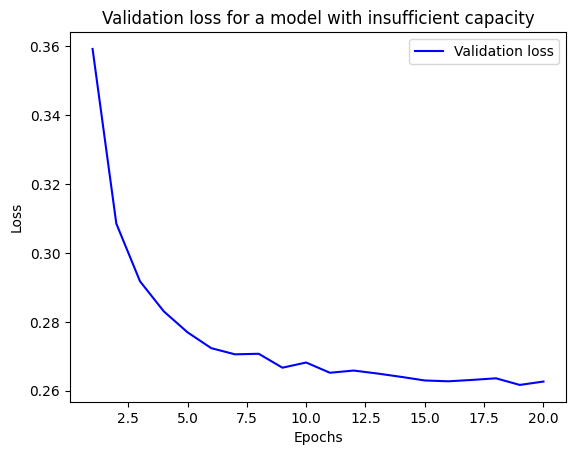

In [162]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("effect_of_insufficient_model_capacity_on_val_loss.png", dpi=300)

Validation metrics seem to stall, or to improve very slowly, instead of peaking and reversing
course. The validation loss goes to 0.26 and just stays there. You can fit, but you can’t
clearly overfit, even after many iterations over the training data. You’re likely to encounter
similar curves often in your career.

Remember that it should always be possible to overfit. Much like the problem “the
training loss doesn’t go down”, this is an issue that can always be solved. If you can’t seem
to be able to overfit, it’s likely a problem with the representational power of your model:
you’re going to need a bigger model. One with more capacity, that is to say, able to store
more information. You can increase representational power by adding more layers, using
bigger layers (layers with more parameters), or using kinds of layers that are more
appropriate for the problem at hand (better architecture priors).

Let’s try training a bigger model, one with two intermediate layers with 128 units each:

In [163]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8991 - loss: 0.3493 - val_accuracy: 0.9537 - val_loss: 0.1660
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9558 - loss: 0.1495 - val_accuracy: 0.9636 - val_loss: 0.1231
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.1031 - val_accuracy: 0.9664 - val_loss: 0.1053
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0774 - val_accuracy: 0.9698 - val_loss: 0.1002
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9811 - loss: 0.0610 - val_accuracy: 0.9728 - val_loss: 0.0907
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0495 - val_accuracy: 0.9737 - val_loss: 0.0885
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0398 - val_accuracy: 0.9747 - val_loss: 0.0922
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.

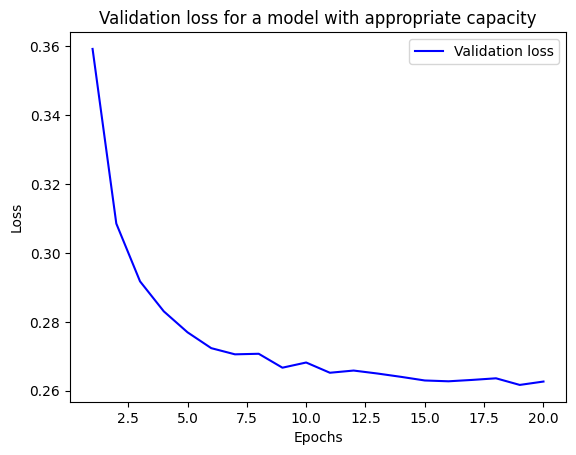

In [164]:
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("effect_of_correct_model_capacity_on_val_loss.png", dpi=300)

The training curves now look exactly like they should: the model fits fast, and starts
overfitting after 8 epochs.

Note that while it is standard to work with models that are way over-parameterized for the
problem at hand, there can definitely be such a thing as too much memorization capacity.
You’ll know your model is too large if it starts overfitting right away. Here’s what happens
for a MNIST model with three intermediate layers with 2048 units each:

In [165]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9243 - loss: 0.2460 - val_accuracy: 0.9721 - val_loss: 0.0958
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9751 - loss: 0.0820 - val_accuracy: 0.9757 - val_loss: 0.0850
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9844 - loss: 0.0513 - val_accuracy: 0.9774 - val_loss: 0.0702
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9890 - loss: 0.0331 - val_accuracy: 0.9739 - val_loss: 0.1067
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9923 - loss: 0.0238 - val_accuracy: 0.9782 - val_loss: 0.0837
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9787 - val_loss: 0.0897
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9963 - loss: 0.0115 - val_accuracy: 0.9745 - val_loss: 0.1128
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.

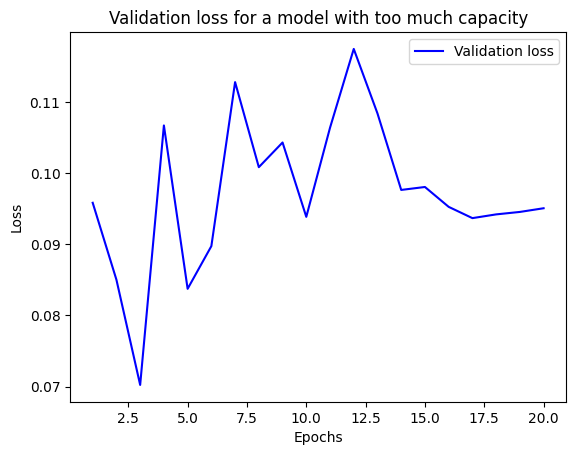

In [166]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("effect_of_excessive_model_capacity_on_val_loss.png", dpi=300)

### Improving generalization

Once your model has shown to have some generalization power and to be able to overfit,
it’s time to switch your focus towards maximizing generalization.

#### Dataset curation

You’ve already learned that generalization in deep learning originates from the latent
structure of your data. If your data makes it possible to smoothly interpolate between
samples, then you will be able to train a deep learning model that generalizes. If your
problem is overly noisy or fundamentally discrete, like, say, list sorting, deep learning will
not help you. Deep learning is curve-fitting, not magic.

As such, it is essential that you make sure that you’re working with an appropriate
dataset. Spending more effort and money on data collection almost always yields a much
greater return on investment than spending the same on developing a better model.

Make sure you have enough data. Remember that you need a dense
sampling of the input-cross-output space. More data will yield a better
model. Sometimes, problems that seem impossible at first become
solvable with a larger dataset.

Minimize labeling errors – visualize your inputs to check for anomalies,
and proof-read your labels.

Clean your data and deal with missing values (we cover this in the next
chapter).

If you have many features and you aren’t sure which ones are actually
useful, do feature selection.

A particularly important way you can improve the generalization potential of your data is
feature engineering. For most machine learning problems, feature engineering is a key
ingredient for success. Let’s take a look.

#### Feature engineering

Feature engineering is the process of using your own knowledge about the data and about
the machine-learning algorithm at hand (in this case, a neural network) to make the
algorithm work better by applying hardcoded (non-learned) transformations to the data
before it goes into the model. In many cases, it isn’t reasonable to expect a machinelearning
model to be able to learn from completely arbitrary data. The data needs to be
presented to the model in a way that will make the model’s job easier.

Let’s look at an intuitive example. Suppose you’re trying to develop a model that can
take as input an image of a clock and can output the time of day (see Figure 5.17).

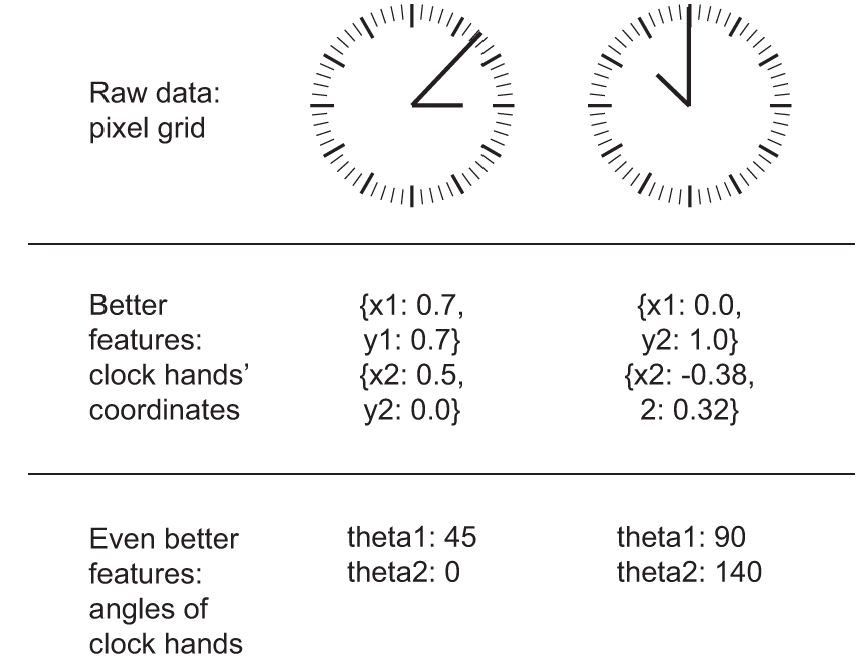

If you choose to use the raw pixels of the image as input data, then you have a difficult
machine-learning problem on your hands. You’ll need a convolutional neural network to
solve it, and you’ll have to expend quite a bit of computational resources to train the
network.

But if you already understand the problem at a high level (you understand how humans
read time on a clock face), then you can come up with much better input features for a
machine-learning algorithm: for instance, it’s easy to write a five-line Python script to
follow the black pixels of the clock hands and output the (x, y) coordinates of the tip of
each hand. Then a simple machine-learning algorithm can learn to associate these
coordinates with the appropriate time of day.

You can go even further: do a coordinate change, and express the (x, y) coordinates as
polar coordinates with regard to the center of the image. Your input will become the angle
theta of each clock hand. At this point, your features are making the problem so easy that
no machine learning is required; a simple rounding operation and dictionary lookup are
enough to recover the approximate time of day.

That’s the essence of feature engineering: making a problem easier by expressing it in a
simpler way. Make the latent manifold smoother, simpler, better-organized. It usually
requires understanding the problem in depth.

Before deep learning, feature engineering used to be the most important part of the
machine learning workflow, because classical shallow algorithms didn’t have hypothesis
spaces rich enough to learn useful features by themselves. The way you presented the data
to the algorithm was absolutely critical to its success. For instance, before convolutional
neural networks became successful on the MNIST digit-classification problem, solutions
were typically based on hardcoded features such as the number of loops in a digit image,
the height of each digit in an image, a histogram of pixel values, and so on.

Fortunately, modern deep learning removes the need for most feature engineering,
because neural networks are capable of automatically extracting useful features from raw
data. Does this mean you don’t have to worry about feature engineering as long as you’re
using deep neural networks? No, for two reasons:

Good features still allow you to solve problems more elegantly while using
fewer resources. For instance, it would be ridiculous to solve the problem
of reading a clock face using a convolutional neural network.

Good features let you solve a problem with far less data. The ability of
deep-learning models to learn features on their own relies on having lots
of training data available; if you have only a few samples, then the
information value in their features becomes critical.

#### Using early stopping

In deep learning, we always use models that are vastly over-parameterized: they have way
more degrees of freedom than the minimum necessary to fit to the latent manifold of the
data. This over-parameterization is not an issue, because you never fully fit a deep learning
model. Such a fit wouldn’t generalize at all. You will always interrupt training long before
you’ve reached the minimum possible training loss.

Finding the exact point during training where you’ve reached the most generalizable fit –
the exact boundary between an underfit curve and an overfit curve – is one of the most
effective things you can do to improve generalization.

In the examples from the previous chapter, we would start by training our models for
longer than needed to figure out the number of epochs that yielded the best validation
metrics, then we would retrain a new model for exactly that number of epochs. This is
pretty standard. However, it requires you to do redundant work, which can sometimes be
expensive. Naturally, you could just save your model at the end of each epoch, then once
you’ve found the best epoch, reuse the closest saved model you have. In Keras, it’s typical
to do this with an EarlyStopping callback, which will interrupt training as soon as
validation metrics have stopped improving, while remembering the best known model state.
You’ll learn to use callbacks in Chapter 7.

#### Regularizing your model

Regularization techniques are a set of best practices that actively impede the model’s ability
to fit perfectly to the training data, with the goal of making the model perform better during
validation. This is called “regularizing” the model, because it tends to make the model
simpler, more “regular”, its curve smoother, more “generic” – thus less specific to the
training set and better able to generalize by more closely approximating the latent manifold
of the data. Keep in mind that “regularizing” a model is a process that should always be
guided by an accurate evaluation procedure. You will only achieve generalization if you can
measure it.

Let’s review some of the most common regularization techniques and apply them in
practice to improve the movie-classification model from Chapter 4.

##### Reducing the network's size

You’ve already learned that a model that is too small will not overfit. The simplest way to
mitigate overfitting is to reduce the size of the model (the number of learnable parameters
in the model, determined by the number of layers and the number of units per layer). If the
model has limited memorization resources, it won’t be able to simply memorize its training
data. In order to minimize its loss, it will have to resort to learning compressed
representations that have predictive power regarding the targets – precisely the type of
representations we’re interested in. At the same time, keep in mind that you should use
models that have enough parameters that they don’t underfit: your model shouldn’t be
starved for memorization resources. There is a compromise to be found between too much
capacity and not enough capacity.

Unfortunately, there is no magical formula to determine the right number of layers or the
right size for each layer. You must evaluate an array of different architectures (on your
validation set, not on your test set, of course) in order to find the correct model size for
your data. The general workflow to find an appropriate model size is to start with relatively
few layers and parameters, and increase the size of the layers or add new layers until you
see diminishing returns with regard to validation loss.

Let’s try this on the movie-review classification model. Here’s a condensed version of the
model from Chapter 4:

In [167]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7639 - loss: 0.5903 - val_accuracy: 0.8447 - val_loss: 0.4767
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8813 - loss: 0.3957 - val_accuracy: 0.8678 - val_loss: 0.3669
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9025 - loss: 0.2953 - val_accuracy: 0.8753 - val_loss: 0.3173
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9215 - loss: 0.2359 - val_accuracy: 0.8832 - val_loss: 0.2883
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9313 - loss: 0.1993 - val_accuracy: 0.8896 - val_loss: 0.2764
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9431 - loss: 0.1701 - val_accuracy: 0.8910 - val_loss: 0.2739
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9516 - loss: 0.1472 - val_accuracy: 0.8865 - val_loss: 0.2860
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9591 - loss: 0.1284 - val_accuracy: 0.8849 - val_lo

Now let’s try to replace it with this smaller model.

In [168]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7039 - loss: 0.6470 - val_accuracy: 0.7990 - val_loss: 0.5953
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8549 - loss: 0.5482 - val_accuracy: 0.8280 - val_loss: 0.5175
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8751 - loss: 0.4690 - val_accuracy: 0.8644 - val_loss: 0.4501
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8897 - loss: 0.4023 - val_accuracy: 0.8683 - val_loss: 0.4020
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8967 - loss: 0.3493 - val_accuracy: 0.8749 - val_loss: 0.3605
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9069 - loss: 0.3072 - val_accuracy: 0.8780 - val_loss: 0.3323
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9145 - loss: 0.2717 - val_accuracy: 0.8840 - val_loss: 0.3074
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9233 - loss: 0.2424 - val_accuracy: 0.8874 - val_los

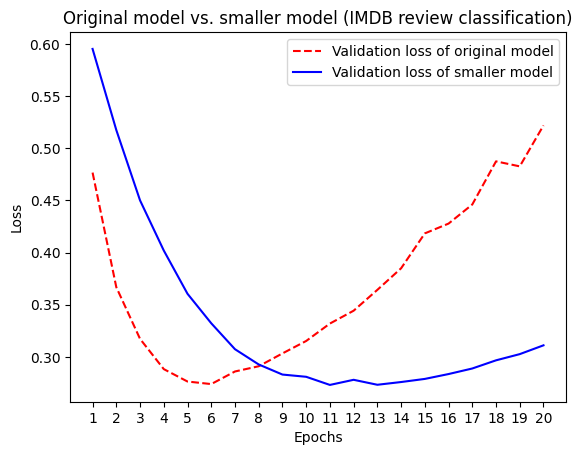

In [169]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.savefig("original_model_vs_smaller_model_imdb.png", dpi=300)

As you can see, the smaller model starts overfitting later than the reference model (after
six epochs rather than four), and its performance degrades more slowly once it starts
overfitting.

Now, let’s add to our benchmark a model that has much more capacity – far more than
the problem warrants.

In [170]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7058 - loss: 0.5746 - val_accuracy: 0.8681 - val_loss: 0.3533
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8636 - loss: 0.3326 - val_accuracy: 0.8672 - val_loss: 0.3149
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9102 - loss: 0.2313 - val_accuracy: 0.8828 - val_loss: 0.2811
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9339 - loss: 0.1834 - val_accuracy: 0.8811 - val_loss: 0.3026
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9462 - loss: 0.1459 - val_accuracy: 0.8836 - val_loss: 0.3162
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9563 - loss: 0.1227 - val_accuracy: 0.8673 - val_loss: 0.3479
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9747 - loss: 0.0760 - val_accuracy: 0.8844 - val_loss: 0.3627
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9797 - loss: 0.0615 - val_accuracy: 0.8834 - 

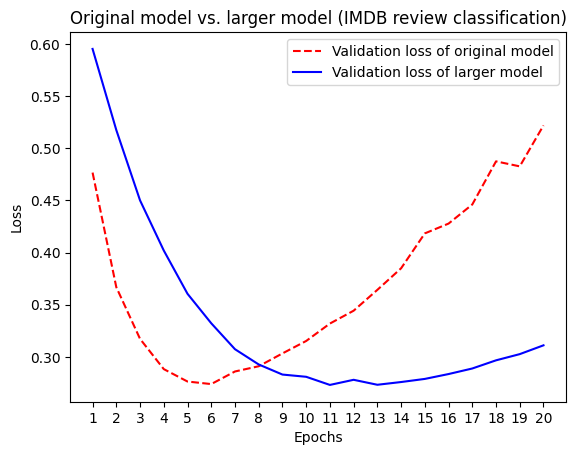

In [171]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.savefig("original_model_vs_larger_model_imdb.png", dpi=300)

The bigger model starts overfitting almost immediately, after just one epoch, and it overfits
much more severely. Its validation loss is also noisier. It gets training loss near zero very
quickly. The more capacity the model has, the more quickly it can model the training data
(resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a
large difference between the training and validation loss).

##### Adding weight regularization

You may be familiar with the principle of Occam’s razor: given two explanations for
something, the explanation most likely to be correct is the simplest one – the one that
makes fewer assumptions. This idea also applies to the models learned by neural networks:
given some training data and a network architecture, multiple sets of weight values
(multiple models) could explain the data. Simpler models are less likely to overfit than
complex ones.

A simple model in this context is a model where the distribution of parameter values has
less entropy (or a model with fewer parameters, as you saw in the previous section). Thus
a common way to mitigate overfitting is to put constraints on the complexity of a model by
forcing its weights to take only small values, which makes the distribution of weight values
more regular. This is called weight regularization, and it’s done by adding to the loss
function of the model a cost associated with having large weights. This cost comes in two
flavors:

L1 regularization – The cost added is proportional to the absolute value
of the weight coefficients (the L1 norm of the weights).

L2 regularization – The cost added is proportional to the square of the
value of the weight coefficients (the L2 norm of the weights). L2
regularization is also called weight decay in the context of neural
networks. Don’t let the different name confuse you: weight decay is
mathematically the same as L2 regularization.

In Keras, weight regularization is added by passing weight regularizer instances to layers as
keyword arguments. Let’s add L2 weight regularization to the movie-review classification
model.

In [172]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7309 - loss: 0.6591 - val_accuracy: 0.8506 - val_loss: 0.5452
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8812 - loss: 0.4581 - val_accuracy: 0.8814 - val_loss: 0.4230
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9060 - loss: 0.3636 - val_accuracy: 0.8844 - val_loss: 0.3788
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9173 - loss: 0.3222 - val_accuracy: 0.8874 - val_loss: 0.3664
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9269 - loss: 0.2958 - val_accuracy: 0.8844 - val_loss: 0.3675
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9309 - loss: 0.2818 - val_accuracy: 0.8806 - val_loss: 0.3777
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9404 - loss: 0.2630 - val_accuracy: 0.8604 - val_loss: 0.4254
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9415 - loss: 0.2584 - val_accuracy: 0.8832 - val_l

l2(0.002) means every coefficient in the weight matrix of the layer will add 0.002 *
weight_coefficient_value ** 2 to the total loss of the model. Note that because this
penalty is only added at training time, the loss for this model will be much higher at
training than at test time.

Figure 5.20 shows the impact of the L2 regularization penalty. As you can see, the model
with L2 regularization has become much more resistant to overfitting than the reference
model, even though both models have the same number of parameters.

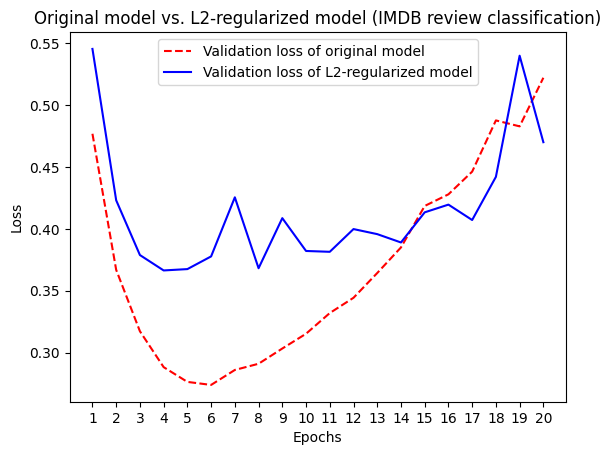

In [173]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.savefig("original_model_vs_l2_regularized_model_imdb.png", dpi=300)

As an alternative to L2 regularization, you can use one of the following Keras weight
regularizers.

In [174]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

Note that weight regularization is more typically used for smaller deep learning models.
Large deep learning models tend to be so over-parameterized that imposing constraints on
weight values does not have much impact on model capacity and generalization. In these
cases, a different regularization technique is preferred: dropout.

##### Adding dropout

Dropout is one of the most effective and most commonly used regularization techniques for
neural networks, developed by Geoff Hinton and his students at the University of Toronto.
Dropout, applied to a layer, consists of randomly dropping out (setting to zero) a number of
output features of the layer during training. Let’s say a given layer would normally return a
vector [0.2, 0.5, 1.3, 0.8, 1.1] for a given input sample during training. After
applying dropout, this vector will have a few zero entries distributed at random: for
example, [0, 0.5, 1.3, 0, 1.1]. The dropout rate is the fraction of the features that are
zeroed out; it’s usually set between 0.2 and 0.5. At test time, no units are dropped out;
instead, the layer’s output values are scaled down by a factor equal to the dropout rate, to
balance for the fact that more units are active than at training time.

Consider a NumPy matrix containing the output of a layer, layer_output, of shape
(batch_size, features). At training time, we zero out at random a fraction of the values
in the matrix:

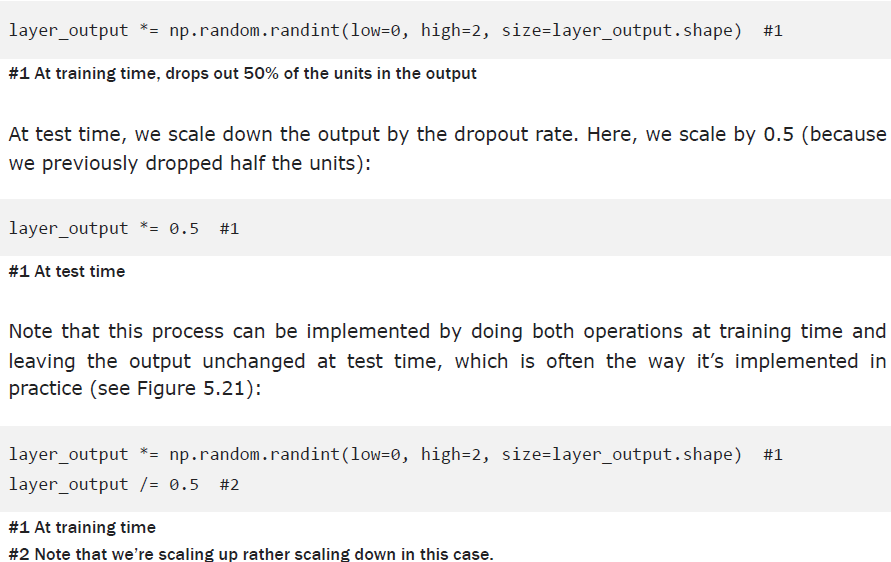

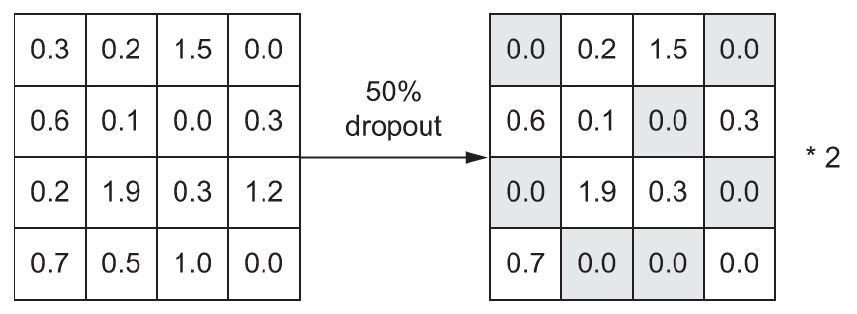

This technique may seem strange and arbitrary. Why would this help reduce overfitting?
Hinton says he was inspired by, among other things, a fraud-prevention mechanism used
by banks. In his own words:

I went to my bank. The tellers kept changing and I asked one of them why. He said
he didn’t know but they got moved around a lot. I figured it must be because it
would require cooperation between employees to successfully defraud the bank. This
made me realize that randomly removing a different subset of neurons on each
example would prevent conspiracies and thus reduce overfitting.

The core idea is that introducing noise in the output values of a layer can break up
happenstance patterns that aren’t significant (what Hinton refers to as conspiracies), which
the model will start memorizing if no noise is present.

In Keras, you can introduce dropout in a model via the Dropout layer, which is applied to
the output of the layer right before it. Let’s add two Dropout layers in the IMDB model to
see how well they do at reducing overfitting.

In [175]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.6016 - loss: 0.6564 - val_accuracy: 0.8400 - val_loss: 0.5817
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7435 - loss: 0.5528 - val_accuracy: 0.8665 - val_loss: 0.4593
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8115 - loss: 0.4693 - val_accuracy: 0.8755 - val_loss: 0.3884
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8515 - loss: 0.4056 - val_accuracy: 0.8743 - val_loss: 0.3595
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8789 - loss: 0.3582 - val_accuracy: 0.8842 - val_loss: 0.3181
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8991 - loss: 0.3172 - val_accuracy: 0.8858 - val_loss: 0.3058
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9135 - loss: 0.2731 - val_accuracy: 0.8876 - val_loss: 0.2862
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9213 - loss: 0.2449 - val_accuracy: 0.8871 - va

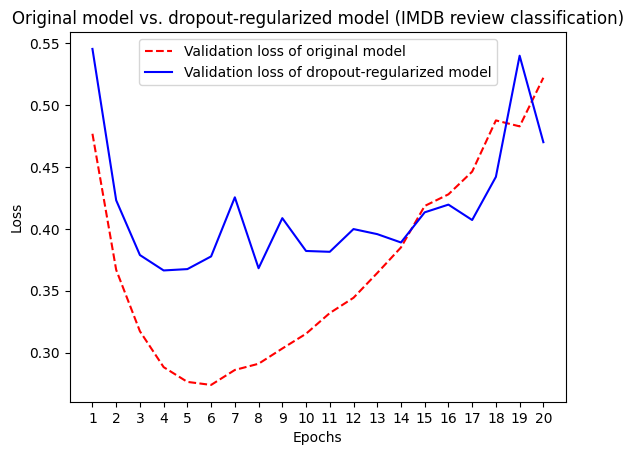

In [176]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.savefig("original_model_vs_dropout_regularized_model_imdb.png", dpi=300)

Figure 5.22 shows a plot of the results. This is a clear improvement over the reference
model – it also seems to be working much better than L2 regularization, since the lowest
validation loss reached has improved.

To recap, these are the most common ways to maximize generalization and prevent
overfitting in neural networks:

Get more training data, or better training data.

Develop better features.

Reduce the capacity of the model.

Add weight regularization (for smaller models).

Add dropout.

### Chapter summary

The purpose of a machine learning model is to generalize: to perform
accurately on never-seen-before inputs. It’s harder than it seems.

A deep neural network achieves generalization by learning a parametric
model that can successfully interpolate between training samples – such
a model can be said to have learned the latent manifold of the training
data. This is why deep learning models can only make sense of inputs
that are very close to what they’ve seen during training.

The fundamental problem in machine learning is the tension between
optimization and generalization: to attain generalization, you must first
achieve a good fit to the training data, but improving your model’s fit to
the training data will inevitably start hurting generalization after a while.
Every single deep learning best practice deals with managing this tension.

The ability of deep learning models to generalize comes from the fact that
they manage to learn to approximate the latent manifold of their data,
and can thus make sense of new inputs via interpolation.

It’s essential to be able to accurately evaluate the generalization power of
your model while you’re developing it. You have at your disposal an array
of evaluation methods, from simple hold-out validation, to K-fold crossvalidation
and iterated K-fold cross-validation with shuffling. Remember
to always keep a completely separate test set for final model evaluation,
since information leaks from your validation data to your model may have
occurred.

When you start working on a model, your goal is first to achieve a model
that has some generalization power and that can overfit. Best practices to
do this include tuning your learning rate and batch size, leveraging better
architecture priors, increasing model capacity, or simply training longer.

As your model starts overfitting, your goal switches to improving
generalization through model regularization. You can reduce your model’s
capacity, add dropout or weight regularization, and use early stopping.
And naturally, a larger or better dataset is always the number one way to
help a model generalize.

# Table of different model types:

If your Yi's are one-hot encoded, use categorical_crossentropy. Examples (for a 3-class classification): [1,0,0] , [0,1,0], [0,0,1]

But if your Yi's are integers, use sparse_categorical_crossentropy. Examples for above 3-class classification problem: [1] , [2], [3]

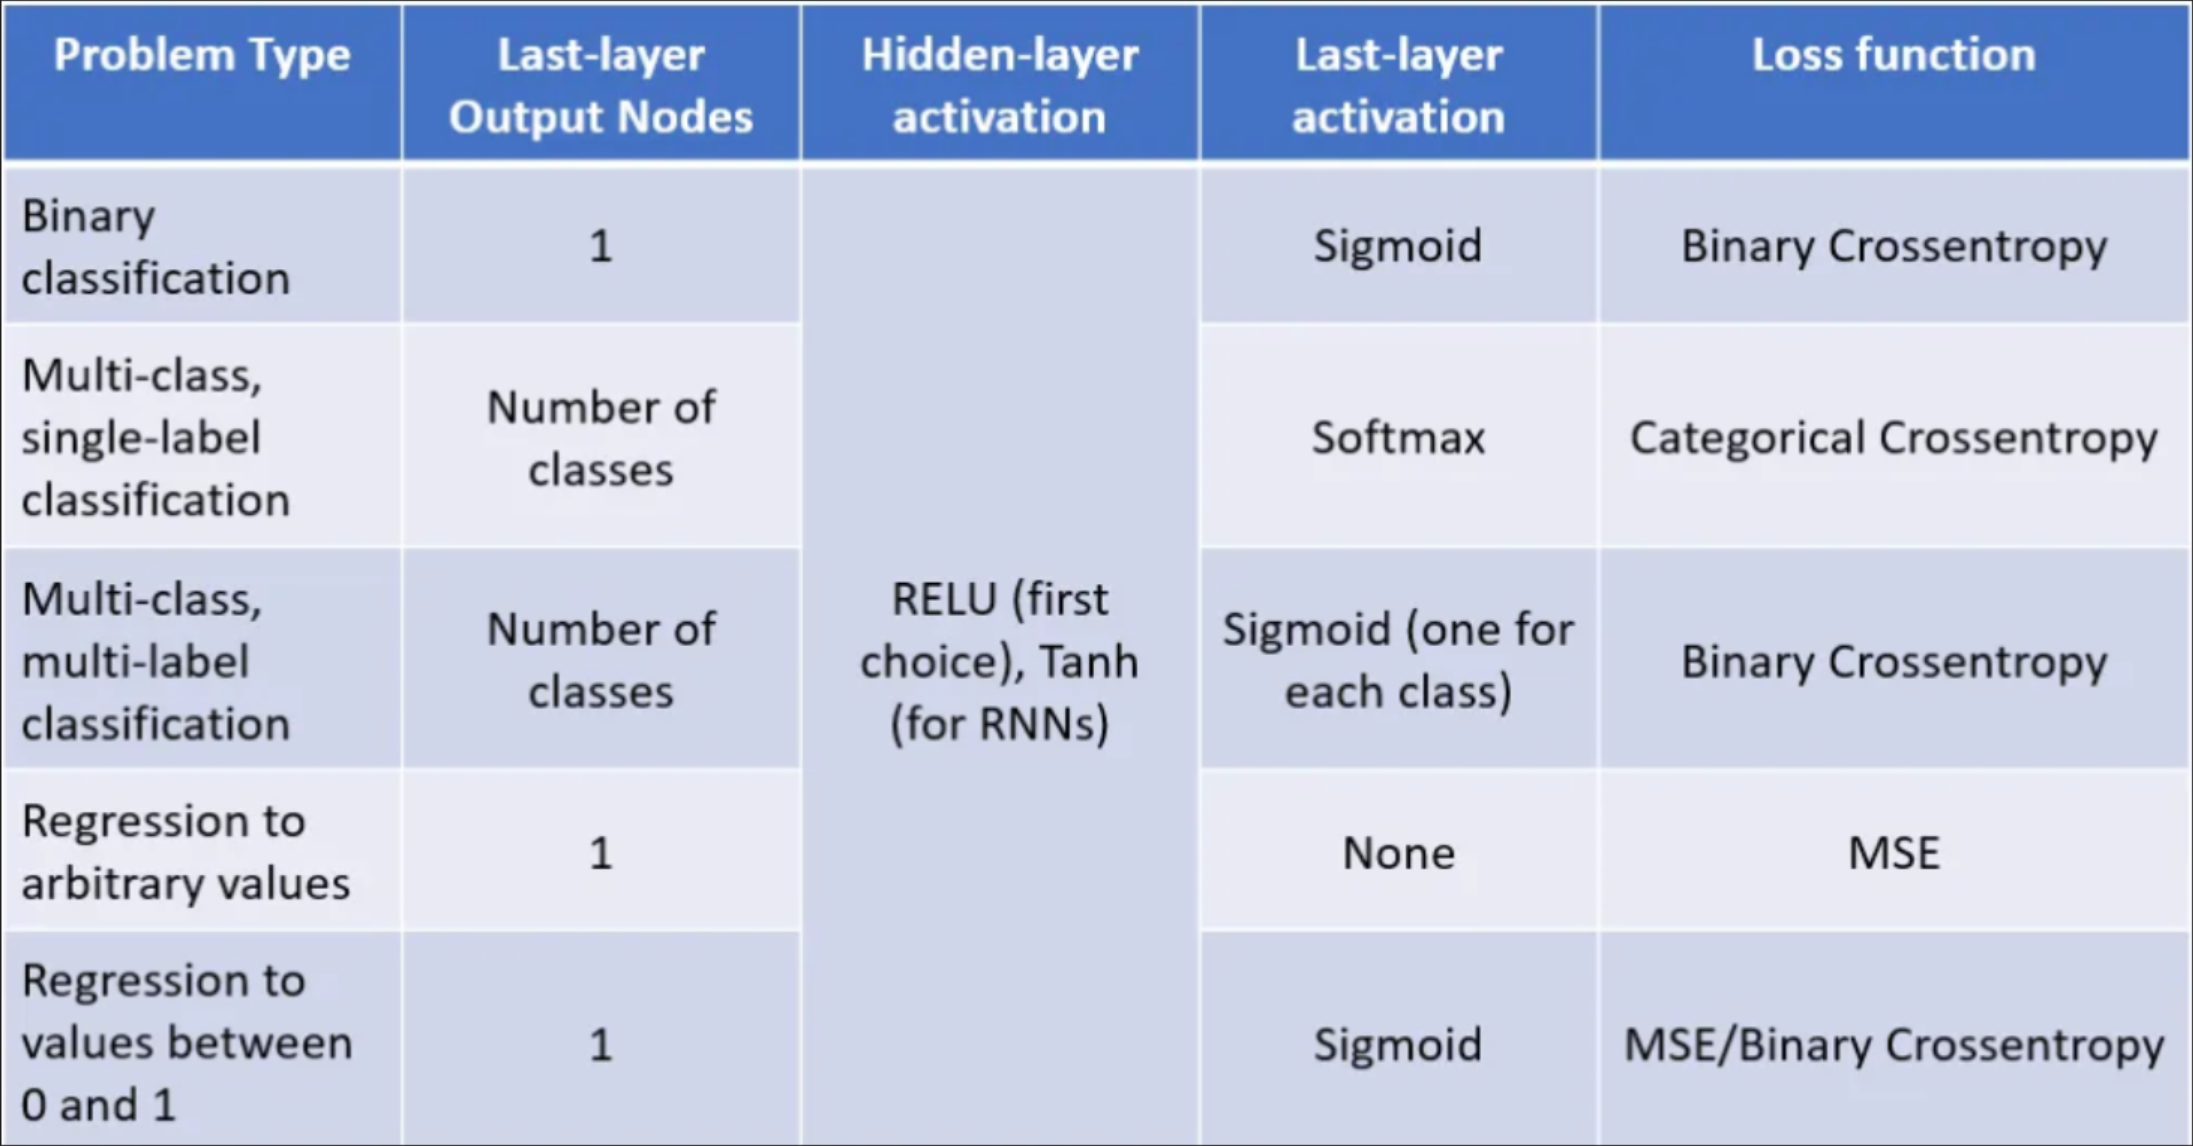